Importing data from the Global Santions Database

In [2]:
import pandas as pd
df = pd.read_csv("/Users/kynesantos/Grad School/Trade Networks/gsdb_v4/GSDB_V4 copy.csv")
df

,case_id,sanctioned_state,sanctioning_state,begin,end,trade,descr_trade,arms,military,financial,travel,other,target_mult,sender_mult,objective,success
0,1,German Democratic Republic,Germany,1949,1973,0,NaN,0,0,0,0,1,0,0,territorial_conflict,success_total
1,2,Pakistan,India,1949,1951,1,"exp_compl,imp_compl",0,0,0,0,0,0,0,policy_change,nego_settlement
2,3,Bulgaria,United States,1950,1963,0,NaN,0,0,1,0,0,0,0,destab_regime,success_part
3,4,Bulgaria,United States,1950,1966,0,NaN,0,0,0,0,1,0,0,destab_regime,failed
4,5,Bulgaria,United States,1950,1959,0,NaN,0,0,0,1,0,0,0,destab_regime,success_part
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1542,1543,Ukraine,Slovakia,2023,2023,0,NaN,1,1,0,0,0,0,0,end_war,ongoing
1543,1544,United Arab Emirates,United States,2023,2023,1,"exp_part,imp_part",0,0,1,0,0,0,0,policy_change,ongoing
1544,1545,United Kingdom,Russia,2023,2023,0,NaN,0,0,0,1,0,0,0,policy_change,ongoing
1545,1546,Zimbabwe,EU,2023,2023,0,NaN,0,0,1,0,0,0,1,democracy,ongoing


In [4]:
replacements = {
    'Korea, North': 'North Korea',
    'Korea, South': 'South Korea',
    'Yemen, North': 'Yemen',
    'Egypt, Arab Rep.': 'Egypt',
    'Congo, Democratic Republic of the': 'DRC',
    'Gambia, The': 'The Gambia'
}

df['sanctioned_state'] = df['sanctioned_state'].replace(replacements)
df['sanctioning_state'] = df['sanctioning_state'].replace(replacements)
df

,case_id,sanctioned_state,sanctioning_state,begin,end,trade,descr_trade,arms,military,financial,travel,other,target_mult,sender_mult,objective,success
0,1,German Democratic Republic,Germany,1949,1973,0,NaN,0,0,0,0,1,0,0,territorial_conflict,success_total
1,2,Pakistan,India,1949,1951,1,"exp_compl,imp_compl",0,0,0,0,0,0,0,policy_change,nego_settlement
2,3,Bulgaria,United States,1950,1963,0,NaN,0,0,1,0,0,0,0,destab_regime,success_part
3,4,Bulgaria,United States,1950,1966,0,NaN,0,0,0,0,1,0,0,destab_regime,failed
4,5,Bulgaria,United States,1950,1959,0,NaN,0,0,0,1,0,0,0,destab_regime,success_part
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1542,1543,Ukraine,Slovakia,2023,2023,0,NaN,1,1,0,0,0,0,0,end_war,ongoing
1543,1544,United Arab Emirates,United States,2023,2023,1,"exp_part,imp_part",0,0,1,0,0,0,0,policy_change,ongoing
1544,1545,United Kingdom,Russia,2023,2023,0,NaN,0,0,0,1,0,0,0,policy_change,ongoing
1545,1546,Zimbabwe,EU,2023,2023,0,NaN,0,0,1,0,0,0,1,democracy,ongoing


In [5]:
df['sanctioned_state'] = df['sanctioned_state'].str.split(', ')
df = df.explode('sanctioned_state')
df['sanctioning_state'] = df['sanctioning_state'].str.split(', ')
df = df.explode('sanctioning_state')
df

,case_id,sanctioned_state,sanctioning_state,begin,end,trade,descr_trade,arms,military,financial,travel,other,target_mult,sender_mult,objective,success
0,1,German Democratic Republic,Germany,1949,1973,0,NaN,0,0,0,0,1,0,0,territorial_conflict,success_total
1,2,Pakistan,India,1949,1951,1,"exp_compl,imp_compl",0,0,0,0,0,0,0,policy_change,nego_settlement
2,3,Bulgaria,United States,1950,1963,0,NaN,0,0,1,0,0,0,0,destab_regime,success_part
3,4,Bulgaria,United States,1950,1966,0,NaN,0,0,0,0,1,0,0,destab_regime,failed
4,5,Bulgaria,United States,1950,1959,0,NaN,0,0,0,1,0,0,0,destab_regime,success_part
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1542,1543,Ukraine,Slovakia,2023,2023,0,NaN,1,1,0,0,0,0,0,end_war,ongoing
1543,1544,United Arab Emirates,United States,2023,2023,1,"exp_part,imp_part",0,0,1,0,0,0,0,policy_change,ongoing
1544,1545,United Kingdom,Russia,2023,2023,0,NaN,0,0,0,1,0,0,0,policy_change,ongoing
1545,1546,Zimbabwe,EU,2023,2023,0,NaN,0,0,1,0,0,0,1,democracy,ongoing


In [73]:
# df.to_csv("/Users/kynesantos/Grad School/Trade Networks/gsdb_v4/GSDB (all years exploded).csv")

Creating a graph for each year, using the START years as indices


In [6]:
import networkx as nx 

digraphs = {}
digraphs_rev = {}
undigraph = {}

for year in range(1949, 2024):
    applicable_sanctions = df[(df["begin"] == year)]

    # Creating the digraph using this year's edges
    G = nx.from_pandas_edgelist(
        applicable_sanctions,
        source="sanctioning_state",
        target="sanctioned_state",
        create_using=nx.DiGraph()
    )
    undirected_G = nx.from_pandas_edgelist(
        applicable_sanctions,
        source="sanctioning_state",
        target="sanctioned_state",
        create_using=nx.Graph()
    )

    # Creating the reversed digraph
    G_rev = G.reverse(copy=True)

    digraphs[year] = G
    digraphs_rev[year] = G_rev
    undigraph[year] = undirected_G

In [7]:
# for CON score

def con(G,u,v):
    # Inputs:
    # G: a digraph
    # u,v: nodes
    return len(set(G.successors(u)) & set(G.successors(v)))

def con_score(G, u):
    con_u = 0
    for v in G.nodes():
        if u != v:
            con_u += con(G,u,v)
    return con_u

def con_centrality(G):
    return {u: con_score(G, u) for u in G.nodes()}


In [8]:
# Testing out code

print(set(digraphs[2014].successors('Canada')))

{'Tanzania', 'Russia', 'South Sudan', 'Ukraine'}


In [9]:
def all_triangles(G, nbunch=None):
    """
    Yields all unique triangles in an undirected graph.

    A triangle is a set of three distinct nodes where each node is connected to
    the other two.

    Parameters
    ----------
    G : NetworkX graph
        An undirected graph.

    nbunch : node, iterable of nodes, or None (default=None)
        If a node or iterable of nodes, only triangles involving at least one
        node in `nbunch` are yielded.
        If ``None``, yields all unique triangles in the graph.

    Yields
    ------
    tuple
        A tuple of three nodes forming a triangle ``(u, v, w)``.

    Examples
    --------
    >>> G = nx.complete_graph(4)
    >>> sorted([sorted(t) for t in all_triangles(G)])
    [[0, 1, 2], [0, 1, 3], [0, 2, 3], [1, 2, 3]]

    Notes
    -----
    This algorithm ensures each triangle is yielded once using an internal node ordering.
    In multigraphs, triangles are identified by their unique set of nodes,
    ignoring multiple edges between the same nodes. Self-loops are ignored.
    Runs in ``O(m * d)`` time in the worst case, where ``m`` the number of edges
    and ``d`` the maximum degree.

    See Also
    --------
    :func:`~networkx.algorithms.triads.all_triads` : related function for directed graphs
    """
    if nbunch is None:
        nbunch = relevant_nodes = G
    else:
        nbunch = dict.fromkeys(G.nbunch_iter(nbunch))
        relevant_nodes = chain(
            nbunch,
            (nbr for node in nbunch for nbr in G.neighbors(node) if nbr not in nbunch),
        )

    node_to_id = {node: i for i, node in enumerate(relevant_nodes)}

    for u in nbunch:
        u_id = node_to_id[u]
        u_nbrs = G._adj[u].keys()
        for v in u_nbrs:
            v_id = node_to_id.get(v, -1)
            if v_id <= u_id:
                continue
            v_nbrs = G._adj[v].keys()
            for w in v_nbrs & u_nbrs:
                if node_to_id.get(w, -1) > v_id:
                    yield u, v, w






In [10]:
for triangle in all_triangles(undigraph[2014]):
    print(triangle)


('Russia', 'Australia', 'Ukraine')
('Russia', 'Canada', 'Ukraine')
('Russia', 'EU', 'Ukraine')
('Russia', 'Norway', 'Ukraine')
('Russia', 'Montenegro', 'Ukraine')
('Russia', 'Albania', 'Ukraine')
('Russia', 'Liechtenstein', 'Ukraine')
('Russia', 'Ukraine', 'Iceland')
('Russia', 'Ukraine', 'Switzerland')
('Russia', 'Ukraine', 'Japan')
('Russia', 'United States', 'Ukraine')
('EU', 'Guinea', 'Ukraine')
('Guinea', 'Montenegro', 'Ukraine')
('Guinea', 'Albania', 'Ukraine')
('Guinea', 'Liechtenstein', 'Ukraine')
('Guinea', 'Norway', 'Ukraine')
('Guinea', 'Ukraine', 'Iceland')
('Guinea', 'Ukraine', 'Moldova')
('Guinea', 'Ukraine', 'Switzerland')


In [11]:
def top3_triangles(G):
    triangles_dict = nx.triangles(G)
    top3 = sorted(triangles_dict.items(), key=lambda x: x[1], reverse=True)[:3]
    return top3

In [12]:
def number_of_triangles(G):
    return sum(1 for _ in all_triangles(G))




In [13]:
def safe_average_clustering(G):
    try:
        return nx.average_clustering(G, count_zeros=False)
    except ZeroDivisionError:
        return 0


In [23]:
# A function for computing avg path length on a disconnected unweighted graph

def safe_avgpathlength(G):
    
    components = nx.number_connected_components(G)
    average = 0

    for C in (G.subgraph(c).copy() for c in nx.connected_components(G)):
        print(nx.average_shortest_path_length(C), C.number_of_nodes()) 
        average += (nx.average_shortest_path_length(C)) * (C.number_of_nodes() / G.number_of_nodes())
    
    print("Average = %s" % average)
    return average

3.1497975708502026 39
1.0 2
1.0 2
Average = 2.949816401468788


2.949816401468788

In [15]:
nx.number_connected_components(undigraph[2014])

3

In [20]:
nx.connected_components(undigraph[2014])

<generator object connected_components at 0x158adfc40>

In [16]:
in_degree = {}
out_degree = {}
con_scores = {}
max_con = {}
min_con = {}
closeness = {}
pageranks = {}
max_pagerank = {}
min_pagerank = {}
# New scores
clustering = {}
num_nodes = {}
num_edges = {}
num_connectedcomponents = {}

for year in range(1949, 2024):
    in_degree[year] = nx.in_degree_centrality(digraphs[year])
    out_degree[year] = nx.out_degree_centrality(digraphs[year])
    con_scores[year] = con_centrality(digraphs[year])
    closeness[year] = nx.closeness_centrality(digraphs[year])
    max_con[year] = max(con_scores[year].values()) if con_scores[year] else None
    min_con[year] = min(con_scores[year].values()) if con_scores[year] else None
    pageranks[year] = nx.pagerank(digraphs_rev[year])
    max_pagerank[year] = max(pageranks[year].values()) if pageranks[year] else None
    min_pagerank[year] = min(pageranks[year].values()) if pageranks[year] else None
    clustering[year] = safe_average_clustering(undigraph[year])
    
    

In [17]:
# Implementing LKL scores
def LKL_score(G,u,year):

    # Get normalized CON score
    if ((max_con[year] - min_con[year]) > 0):
        con_norm = (con_score(G,u) - min_con[year]) / (max_con[year] - min_con[year])
    else:
        con_norm = 0

    # Get normalized pagerank
    if (max_pagerank[year] - min_pagerank[year] > 0): 
        pagerank_norm = (pageranks[year][u] - min_pagerank[year]) / (max_pagerank[year] - min_pagerank[year])
    else:
        pagerank_norm = 0
        
    return con_norm - pagerank_norm


def LKL_centrality(G, year):
    return {u: LKL_score(G, u, year) for u in G.nodes()}

LKL = {}

for year in range(1949, 2024):
    LKL[year] = LKL_centrality(digraphs[year], year)


In [24]:
centrality_maps = {
    "pagerank": pageranks,
    "in degree": in_degree,
    "out degree": out_degree,
    "con": con_scores,
    "closeness": closeness,
    "LKL": LKL,
}

rows = {}

for name, yearly_scores in centrality_maps.items():
    rows[name] = {
        year: max(scores, key=scores.get) if scores else None
        for year, scores in yearly_scores.items()
    }

# add a row for clustering values
rows['clustering'] = {
    year: clustering.get(year, None)  # default to None if missing
    for year in range(1949, 2024)
}

rows['# nodes'] = {year: digraphs[year].number_of_nodes() for year in range(1949, 2024)}
rows['# edges'] = {year: digraphs[year].number_of_edges() for year in range(1949, 2024)}
rows['# triangles'] = {year: number_of_triangles(undigraph[year]) for year in range(1949, 2024)}
rows['top triangle players'] = {year: top3_triangles(undigraph[year]) for year in range(1949, 2024)}
rows['# of connected components'] = {year: nx.number_connected_components(undigraph[year]) for year in range(1949, 2024)}
rows['Average path length'] = {year: safe_avgpathlength(undigraph[year]) for year in range(1949, 2024)}

sanctions_table = pd.DataFrame(rows).T.sort_index(axis=1)

1.0 2
1.0 2
Average = 1.0
2.876190476190476 15
1.8 5
1.0 2
Average = 2.4610389610389607
2.1904761904761907 7
1.0 2
Average = 1.925925925925926
1.3333333333333333 3
1.0 2
Average = 1.2
Average = 0
1.0 2
1.8 5
1.0 2
1.0 2
Average = 1.3636363636363638
1.0 2
1.0 2
Average = 1.0
1.8 5
Average = 1.8
1.0 2
1.0 2
1.5 4
1.0 2
1.0 2
Average = 1.1666666666666665
1.3333333333333333 3
1.3333333333333333 3
Average = 1.3333333333333333
1.0 2
Average = 1.0
1.3333333333333333 3
1.8666666666666667 6
1.0 2
Average = 1.5636363636363635
1.0 2
1.6666666666666667 6
1.0 2
1.0 2
Average = 1.3333333333333335
2.3333333333333335 12
1.0 2
1.3333333333333333 3
Average = 2.0
2.704761904761905 15
1.0 2
Average = 2.504201680672269
1.0 2
1.5 4
1.0 2
1.5 4
1.0 2
Average = 1.2857142857142856
1.0 2
1.3333333333333333 3
1.0 2
1.6666666666666667 6
Average = 1.3846153846153846
2.3484848484848486 12
Average = 2.3484848484848486
1.5 4
1.8666666666666667 6
1.0 2
Average = 1.6
1.0 2
1.6 5
1.6666666666666667 6
1.0 2
1.0 2
Average

In [25]:
sanctions_table

,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
pagerank,Germany,United States,United States,United States,None,United States,United States,United States,Indonesia,United States,...,Russia,Russia,United States,United States,United States,United States,United States,United States,United States,United States
in degree,German Democratic Republic,China,China,China,None,North Vietnam,North Korea,Egypt,Transjordan,Cuba,...,Guinea,Burundi,Iran,Qatar,Saudi Arabia,Turkey,Belarus,Belarus,Russia,Russia
out degree,Germany,United States,United States,ChinCom,None,United States,United States,United States,Indonesia,United States,...,EU,UN,United States,United States,United States,United States,United States,United States,United States,United States
con,Germany,CoCom,Hong Kong,ChinCom,None,United States,United States,United States,Egypt,United States,...,EU,EU,Australia,Chad,United States,EU,EU,United Kingdom,United States,United States
closeness,German Democratic Republic,China,China,China,None,North Vietnam,North Korea,Egypt,Transjordan,Cuba,...,Guinea,Burundi,Iran,Qatar,Saudi Arabia,Turkey,Belarus,Belarus,Russia,Russia
LKL,German Democratic Republic,CoCom,Hong Kong,ChinCom,None,South Vietnam,North Korea,United Kingdom,Egypt,Cuba,...,Norway,Belgium,Australia,Chad,France,EU,EU,EU,EU,United Kingdom
clustering,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.447025,0.0,0.0,0.0,0.0,0.0,0.445326,0.541191,0.426401,0.391982
# nodes,4,22,9,5,0,11,4,5,12,6,...,43,24,19,48,36,36,41,80,86,104
# edges,2,19,7,3,0,7,2,4,7,4,...,72,19,16,50,33,31,50,108,129,169
# triangles,0,0,0,0,0,0,0,0,0,0,...,19,0,0,0,0,0,1,7,7,14


In [26]:

sanctions_table.to_csv("/Users/kynesantos/Grad School/Trade Networks/gsdb_v4/Sanction Info Table (start years) v2.csv")

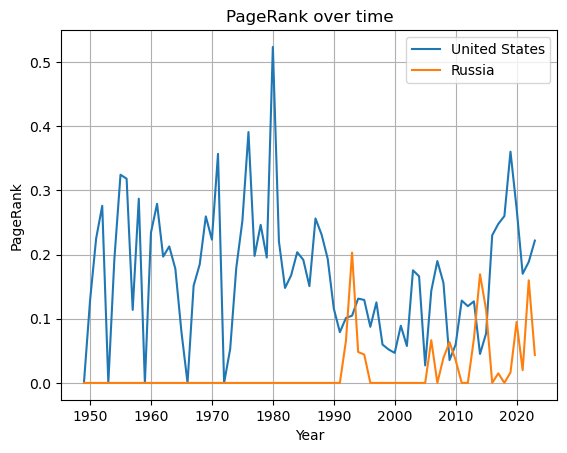

In [17]:
import matplotlib.pyplot as plt

pagerank_countries = ["United States", "Russia"]
years = [i for i in range(1949,2024)]

data = {c: [pageranks[year].get(c, 0.0) for year in years] for c in pagerank_countries}

for c in pagerank_countries:
    plt.plot(years, data[c], label=c)

plt.xlabel("Year")
plt.ylabel("PageRank")
plt.title("PageRank over time")
plt.legend()
plt.grid(True)
plt.show()

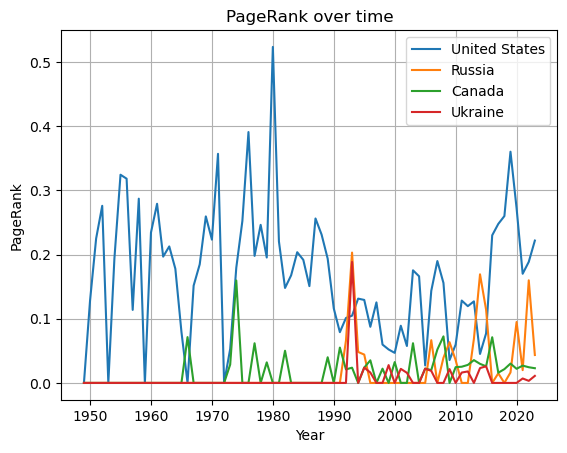

In [18]:

pagerank_countries = ["United States", "Russia", "Canada", "Ukraine"]
years = [i for i in range(1949,2024)]

data = {c: [pageranks[year].get(c, 0.0) for year in years] for c in pagerank_countries}

for c in pagerank_countries:
    plt.plot(years, data[c], label=c)

plt.xlabel("Year")
plt.ylabel("PageRank")
plt.title("PageRank over time")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

countries = ["United States", "Russia", "Canada", "Ukraine"]
years = [i for i in range(1949,2024)]

data = {c: [pageranks[year].get(c, 0.0) for year in years] for c in countries}

for c in countries:
    plt.plot(years, data[c], label=c)

plt.xlabel("Year")
plt.ylabel("PageRank")
plt.title("PageRank over time")
plt.legend()
plt.grid(True)
plt.show()

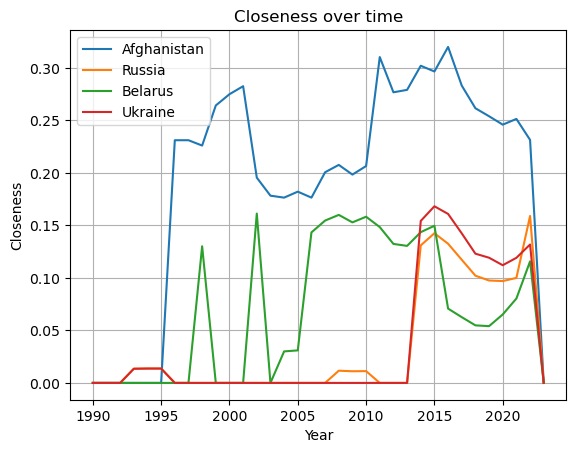

In [71]:


closeness_countries = ["Afghanistan", "Russia", "Belarus", "Ukraine"]
years = [i for i in range(1990,2024)]

data = {c: [closeness[year].get(c, 0.0) for year in years] for c in closeness_countries}

for c in closeness_countries:
    plt.plot(years, data[c], label=c)

plt.xlabel("Year")
plt.ylabel("Closeness")
plt.title("Closeness over time")
plt.legend()
plt.grid(True)
plt.show()

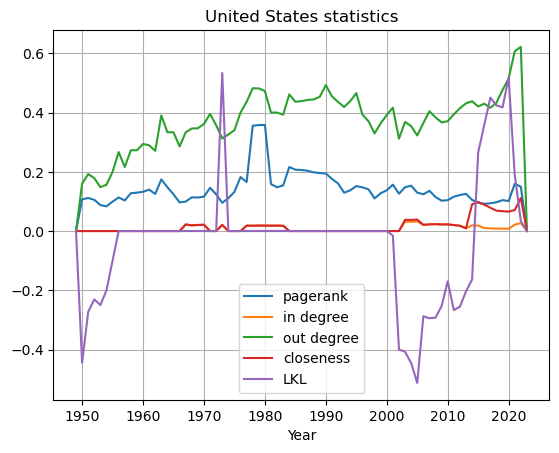

In [107]:
years = [i for i in range(1949,2024)]
centrality_maps = {
    "pagerank": pageranks,
    "in degree": in_degree,
    "out degree": out_degree,
    "closeness": closeness,
    "LKL": LKL,
}

data = {name: [centrality_maps[name][year].get("United States", 0.0) for year in years] for name in centrality_maps}

for name, values in data.items():
    plt.plot(years, values, label=name)

plt.xlabel("Year")
plt.ylabel("")
plt.title("United States statistics")
plt.legend()
plt.grid(True)
plt.show()

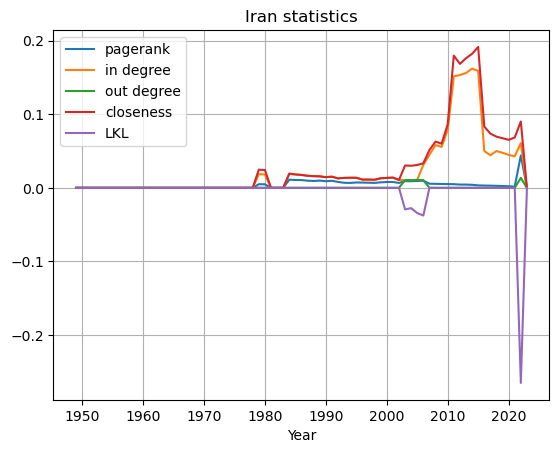

In [108]:

data = {name: [centrality_maps[name][year].get("Iran", 0.0) for year in years] for name in centrality_maps}

for name, values in data.items():
    plt.plot(years, values, label=name)

plt.xlabel("Year")
plt.ylabel("")
plt.title("Iran statistics")
plt.legend()
plt.grid(True)
plt.show()

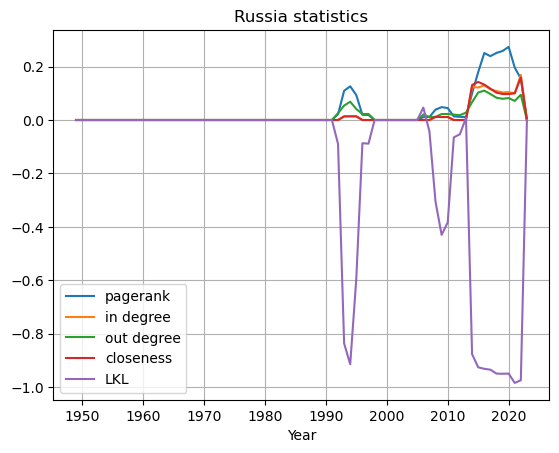

In [109]:

data = {name: [centrality_maps[name][year].get("Russia", 0.0) for year in years] for name in centrality_maps}

for name, values in data.items():
    plt.plot(years, values, label=name)

plt.xlabel("Year")
plt.ylabel("")
plt.title("Russia statistics")
plt.legend()
plt.grid(True)
plt.show()

# Creating the Competition Graph

In [29]:
competition_graph = nx.Graph()
for year in range(1949, 2024):
    for u in digraphs[year].nodes():
        for v in digraphs[year].nodes():
            if (u != v) & con(digraphs[year], u, v) > 0:
                competition_graph.add_edge(u, v, year=year)



In [30]:
comp_mst = nx.minimum_spanning_tree(competition_graph)
mst_edges = nx.to_pandas_edgelist(comp_mst)
mst_edges.to_csv("/Users/kynesantos/Grad School/Trade Networks/gsdb_v4/Competition graph (MST).csv")

In [113]:
comp_edges = nx.to_pandas_edgelist(competition_graph)
comp_edges.to_csv("/Users/kynesantos/Grad School/Trade Networks/gsdb_v4/Competition graph.csv")

In [118]:
comp_edges[comp_edges['year']==2014]

,source,target,year
116,New Zealand,Australia,2014
120,New Zealand,Switzerland,2014
123,New Zealand,Japan,2014
133,New Zealand,Ukraine,2014
192,United Kingdom,Spain,2014
...,...,...,...
1067,Armenia,Bosnia and Herzegovina,2014
1068,Armenia,Moldova,2014
1103,Ukraine,Bosnia and Herzegovina,2014
1105,Ukraine,Georgia,2014


# The Common Sanctioner Graph
Composing a graph where 2 countries are connected if they are ever sanctioned by the same country

In [27]:
sanction_graph = nx.Graph()
for year in range(2010,2023):
    sanction_graph.add_edges_from(list(undigraph[year].edges()))

In [28]:
nx.minimum_spanning_tree(sanction_graph)

In [135]:
nx.maximal_independent_set(sanction_graph, nodes=['Russia'])

['Russia',
 'Mozambique',
 'South Sudan',
 'Djibouti',
 'Latvia',
 'Panama',
 'Lesotho',
 'Uganda',
 'Gambia',
 'Philippines',
 'Maldives',
 'Syria',
 'Argentina',
 'Netherlands',
 'Nicaragua',
 'Tunisia',
 'Costa Rica',
 'Israel',
 'Korea',
 'Brazil',
 'Belgium',
 'Ghana',
 'Pakistan',
 'Honduras',
 'Mexico',
 'Somalia',
 'Libya',
 'Equatorial Guinea',
 'Tanzania',
 'Jamaica',
 'Hong Kong',
 'United Arab Emirates',
 'Bangladesh',
 'Ethiopia (excludes Eritrea)',
 'Nigeria',
 'Chad',
 ' Norway',
 'Sudan',
 'Arab Rep.',
 'Kuwait',
 'Nepal',
 'Azerbaijan',
 'South Vietnam',
 'North Korea',
 'Morocco',
 'Comoros',
 'South Africa',
 'Kimberly Process Participants',
 'Malawi',
 'Colombia',
 'Paraguay',
 'Yemen',
 'Sierra Leone',
 'Greece',
 'Hungary',
 'Estonia',
 'Guinea',
 'Belize',
 'Bahrain',
 'Saudi Arabia',
 'Transjordan',
 'Dominican Republic',
 'Peru',
 'Fiji',
 'Czech Republic',
 'Cameroon',
 'Niger',
 'Zambia',
 'Indonesia',
 'Malta',
 'Ceylon',
 'El Salvador',
 'Kenya',
 'DRC',
 '

In [136]:
nx.maximal_independent_set(sanction_graph, nodes=['Canada'])

['Canada',
 'Jordan',
 'Albania',
 'Estonia',
 'Ethiopia (excludes Eritrea)',
 'Nepal',
 'Ecuador',
 'South Vietnam',
 'Malawi',
 'Korea',
 'Yemen',
 'Kimberly Process Participants',
 'Thailand',
 'The',
 'Bolivia',
 'Djibouti',
 'Terrorist Organizations (Al-Qaeda)',
 'Malta',
 'Guyana',
 'Algeria',
 ' Norway',
 'El Salvador',
 'Cameroon',
 'Zimbabwe',
 'The Gambia',
 'Terrorist Organizations (Taliban)',
 'African Union',
 'Lesotho',
 'Iraq',
 'Germany',
 'Brazil',
 'Bulgaria',
 'Mauritania',
 'Georgia',
 'MERCOSUR',
 'Transjordan',
 'Fiji',
 'Iceland',
 'Ceylon',
 'Switzerland',
 'Laos',
 'League of Arab States',
 'Tajikistan',
 'Philippines',
 'G7',
 'Slovenia',
 'South Africa',
 'Greece',
 'Kosovo',
 'Hungary',
 'Belgium',
 'UNASUR',
 'Maldives',
 'Gambia',
 'Norway',
 'Azerbaijan',
 'Liechtenstein',
 'Comoros',
 'DRC',
 'Israel',
 'Sierra Leone',
 'Colombia',
 'Macedonia',
 'Hong Kong',
 'New Zealand',
 'Honduras',
 'Panama',
 'Bahrain',
 'Armenia',
 'Lebanon',
 'Netherlands',
 'Be

In [137]:
nx.maximal_independent_set(sanction_graph, nodes=['Israel'])

['Israel',
 'Poland',
 'The Gambia',
 'Monaco',
 'Afghanistan',
 'South Korea',
 'Kimberly Process Participants',
 'Kyrgyzstan',
 'Thailand',
 'Jamaica',
 'Ghana',
 'India',
 'Honduras',
 'Guyana',
 'Egypt',
 'Slovenia',
 'Guinea',
 'Myanmar',
 'MERCOSUR',
 'Latvia',
 'Kosovo',
 'League of Arab States',
 'Azerbaijan',
 'Brazil',
 'Yemen',
 'Burkina Faso',
 'Iraq',
 'Guinea-Bissau',
 'Indonesia',
 'Guatemala',
 'Somalia',
 'France',
 'Costa Rica',
 'Maldives',
 'Angola',
 'UNASUR',
 'Argentina',
 'New Zealand',
 'Kenya',
 'Lithuania',
 ' Norway',
 'Cambodia',
 'Hungary',
 'Cameroon',
 'Netherlands',
 'Terrorist Organizations (Al-Qaeda)',
 'Malawi',
 'Belgium',
 'Hong Kong',
 'Equatorial Guinea',
 'Mozambique',
 'Ethiopia (excludes Eritrea)',
 'South Africa',
 'Tajikistan',
 'Sudan',
 'Estonia',
 'OIC',
 'Senegal',
 'Jordan',
 'Malagasy Republic',
 'Chad',
 'Tanzania',
 'The',
 'Algeria',
 'Zimbabwe',
 'Pakistan',
 'Terrorist Organizations (Taliban)',
 'United Arab Emirates',
 'Ecuador',

In [138]:
nx.maximal_independent_set(sanction_graph, nodes=['Palestine'])

['Palestine',
 'Guinea-Bissau',
 'Kenya',
 'Central African Republic',
 'Senegal',
 'Zambia',
 'Algeria',
 'Rwanda',
 'Serbia',
 'Fiji',
 'Angola',
 'Estonia',
 'North Korea',
 'Iran',
 'Indonesia',
 'Terrorist Organizations (Al-Qaeda)',
 'Jordan',
 'Burundi',
 'Nepal',
 'Greece',
 'Kyrgyzstan',
 'Eritrea',
 'Terrorist Organizations (Taliban)',
 'Bolivia',
 'Cambodia',
 'Gambia',
 'Guyana',
 'Belize',
 'Slovenia',
 'Bulgaria',
 'Uganda',
 'MERCOSUR',
 'League of Arab States',
 'Azerbaijan',
 'Iraq',
 'Finland',
 'Panama',
 'Sudan',
 'Cameroon',
 'Nigeria',
 'Malawi',
 'Nicaragua',
 'Georgia',
 'Kuwait',
 'Saudi Arabia',
 'Argentina',
 'Sierra Leone',
 'The',
 'Malta',
 'Comoros',
 'Zimbabwe',
 ' Norway',
 'Niger',
 'Laos',
 'Hungary',
 'South Africa',
 'Ecuador',
 'Arab Rep.',
 'DRC',
 'Singapore',
 'Armenia',
 'Chad',
 'Lesotho',
 'Transjordan',
 'El Salvador',
 'Yemen',
 'Mozambique',
 'Haiti',
 'Liberia',
 'Guatemala',
 'Taiwan',
 'Dominican Republic',
 'Maldives',
 'Monaco',
 'Mexi

NameError: name 'G' is not defined